In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
df=pd.read_csv("thyroid_dataset.csv") 

In [3]:
df

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.00000,6.0000,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.00000,15.0000,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.00000,19.0000,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.00000,3.0000,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.00000,3.0000,5.0,116.0,4.0,o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n


In [4]:
X=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [6]:
from sklearn.neighbors import LocalOutlierFactor

In [50]:
clf = LocalOutlierFactor(n_neighbors=12,contamination=0.036)
labels=clf.fit_predict(X)

In [47]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

Text(0, 0.5, 'PC2')

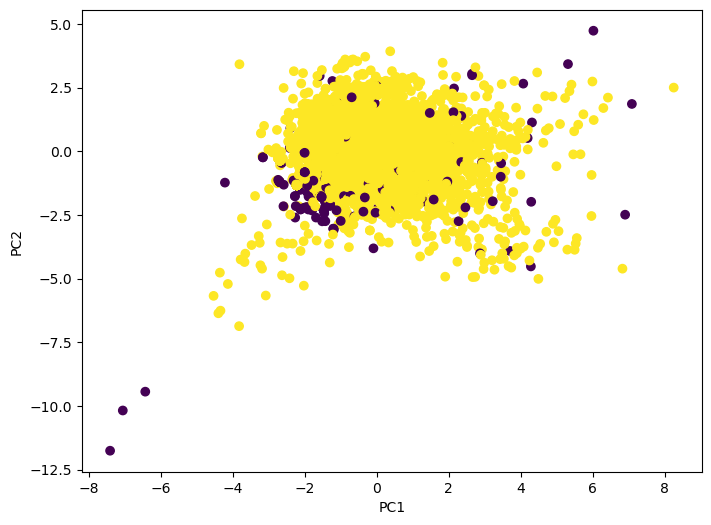

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [52]:
n_outlier=np.sum(labels==-1)
n_normal=np.sum(labels==1)

print("Outlier : ",n_outlier)
print("Normal : ",n_normal)

Outlier :  249
Normal :  6667
